In [1]:
# ================================================================
# BOOK RECOMMENDATION SYSTEM
# FULL EDA + DATA CLEANING SCRIPT
# Dataset: Book-Crossing (Users.csv, Books.csv, Ratings.csv)
# ================================================================
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
# ----------------------------------------------------------------
# SECTION 1: LOAD DATA
# ----------------------------------------------------------------
print("=" * 55)
print("  SECTION 1: LOADING DATA")
print("=" * 55)

users   = pd.read_csv('Users.csv',   encoding='latin-1', on_bad_lines='skip')
ratings = pd.read_csv('Ratings.csv', encoding='latin-1', on_bad_lines='skip')
books   = pd.read_csv('Books.csv',   encoding='latin-1', on_bad_lines='skip')

# Fix Year column type right away
books['Year-Of-Publication'] = pd.to_numeric(books['Year-Of-Publication'], errors='coerce')

print(f"Users   shape : {users.shape}")
print(f"Books   shape : {books.shape}")
print(f"Ratings shape : {ratings.shape}")


  SECTION 1: LOADING DATA
Users   shape : (278858, 3)
Books   shape : (271360, 8)
Ratings shape : (1149780, 3)


In [3]:
# ----------------------------------------------------------------
# SECTION 2: BASIC INFO
# ----------------------------------------------------------------
print("\n" + "=" * 55)
print("  SECTION 2: BASIC INFO")
print("=" * 55)

for name, df in [('USERS', users), ('BOOKS', books), ('RATINGS', ratings)]:
    print(f"\n--- {name} ---")
    print(df.head(3))
    print(df.dtypes)


  SECTION 2: BASIC INFO

--- USERS ---
   User-ID                         Location   Age
0        1               nyc, new york, usa   NaN
1        2        stockton, california, usa  18.0
2        3  moscow, yukon territory, russia   NaN
User-ID       int64
Location     object
Age         float64
dtype: object

--- BOOKS ---
         ISBN            Book-Title           Book-Author  \
0  0195153448   Classical Mythology    Mark P. O. Morford   
1  0002005018          Clara Callan  Richard Bruce Wright   
2  0060973129  Decision in Normandy          Carlo D'Este   

   Year-Of-Publication                Publisher  \
0               2002.0  Oxford University Press   
1               2001.0    HarperFlamingo Canada   
2               1991.0          HarperPerennial   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazon.com/images/P/0002005018.0...   
2  http://images.amazon.com/images/P/0060973129.0... 

In [4]:
# ----------------------------------------------------------------
# SECTION 3: MISSING VALUES (BEFORE CLEANING)
# ----------------------------------------------------------------
print("\n" + "=" * 55)
print("  SECTION 3: MISSING VALUES (BEFORE CLEANING)")
print("=" * 55)

for name, df in [('Users', users), ('Books', books), ('Ratings', ratings)]:
    missing = df.isnull().sum()
    pct     = (missing / len(df) * 100).round(2)
    summary = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
    summary = summary[summary['Missing Count'] > 0]
    print(f"\n{name}:")
    print(summary if not summary.empty else "  No missing values!")

# Key observations:
# - Users  : Age has 39.7% missing → impute with median
# - Books  : Author/Publisher have tiny missing → fill 'Unknown'
# - Books  : Year has invalid values (0, 2050 etc.) → fix
# - Ratings: No missing values


  SECTION 3: MISSING VALUES (BEFORE CLEANING)

Users:
     Missing Count  Missing %
Age         110762      39.72

Books:
                     Missing Count  Missing %
Book-Author                      2        0.0
Year-Of-Publication              3        0.0
Publisher                        2        0.0
Image-URL-L                      3        0.0

Ratings:
  No missing values!


In [5]:
# ----------------------------------------------------------------
# SECTION 4: OUTLIERS / INVALID DATA (BEFORE CLEANING)
# ----------------------------------------------------------------
print("\n" + "=" * 55)
print("  SECTION 4: OUTLIERS / INVALID DATA")
print("=" * 55)

invalid_age  = ((users['Age'] < 5) | (users['Age'] > 100)).sum()
invalid_year = ((books['Year-Of-Publication'] < 1800) |
                (books['Year-Of-Publication'] > 2024)).sum()
implicit_rat = (ratings['Book-Rating'] == 0).sum()
explicit_rat = (ratings['Book-Rating'] > 0).sum()

print(f"Invalid Age entries  (< 5 or > 100) : {invalid_age:,}")
print(f"Invalid Year entries (< 1800 or > 2024): {invalid_year:,}")
print(f"Implicit ratings (= 0) : {implicit_rat:,}  ({implicit_rat/len(ratings)*100:.1f}%)")
print(f"Explicit ratings (1-10): {explicit_rat:,}  ({explicit_rat/len(ratings)*100:.1f}%)")



  SECTION 4: OUTLIERS / INVALID DATA
Invalid Age entries  (< 5 or > 100) : 1,248
Invalid Year entries (< 1800 or > 2024): 4,632
Implicit ratings (= 0) : 716,109  (62.3%)
Explicit ratings (1-10): 433,671  (37.7%)



  SECTION 5: EDA VISUALIZATIONS


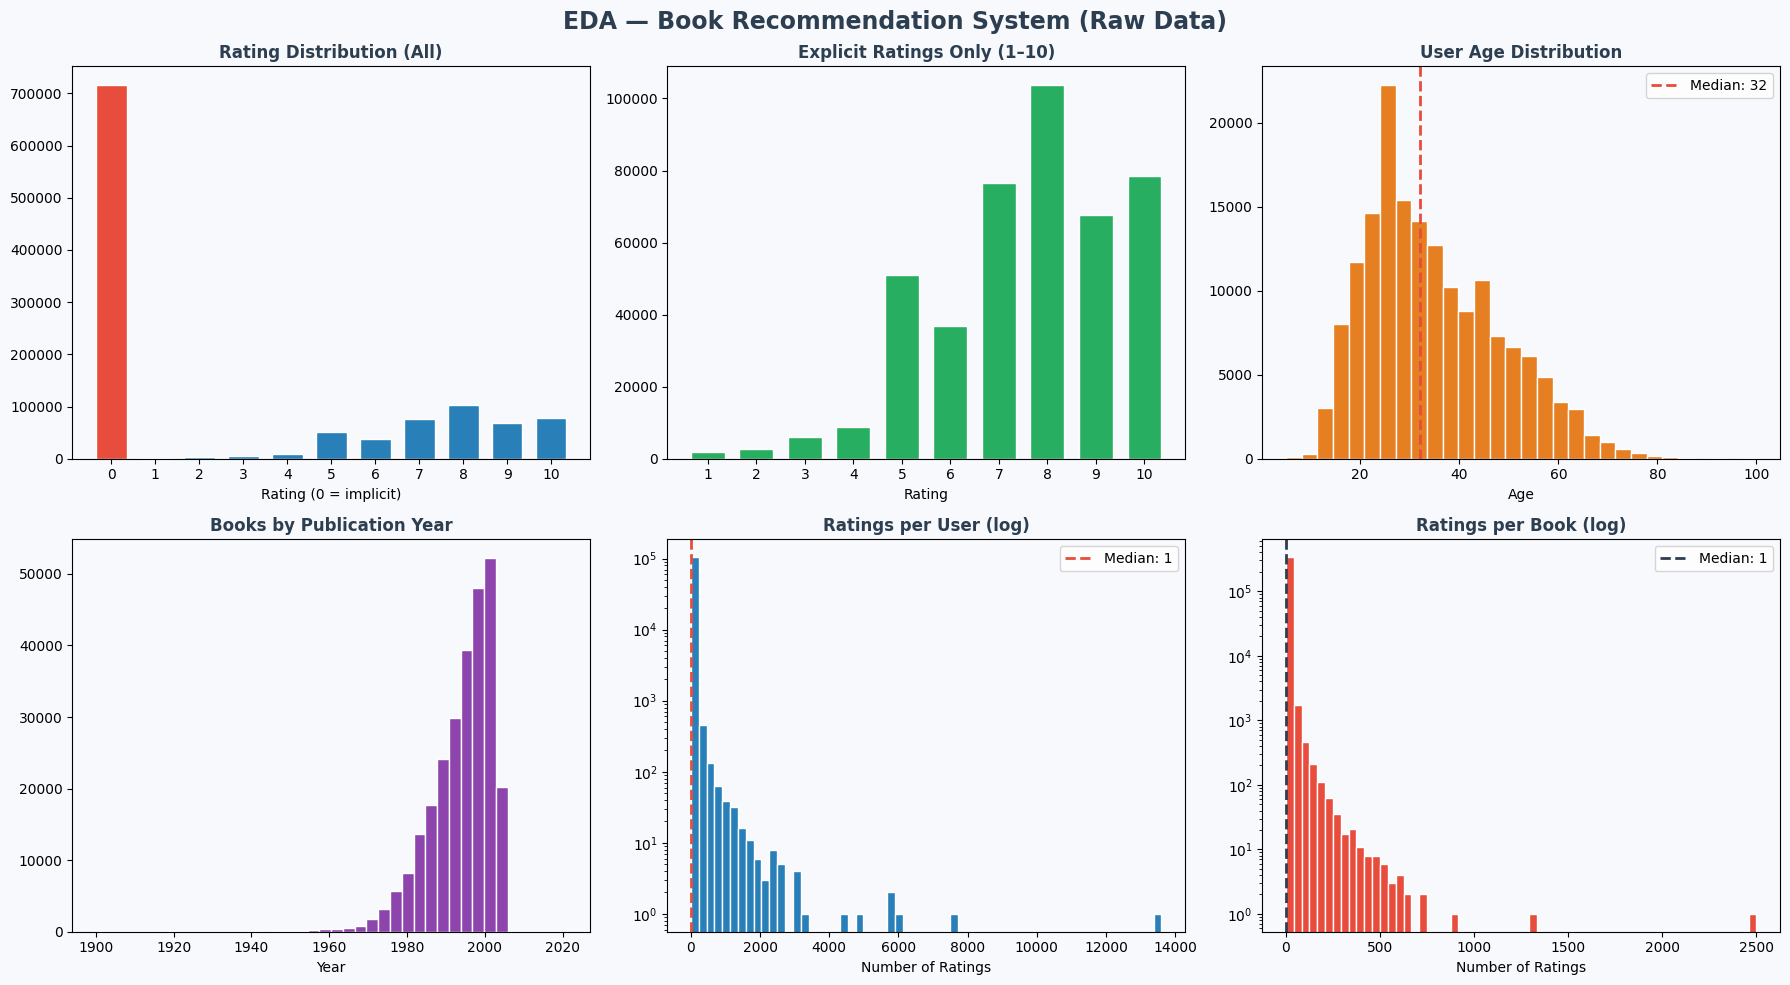

Saved: EDA_1_Overview.png


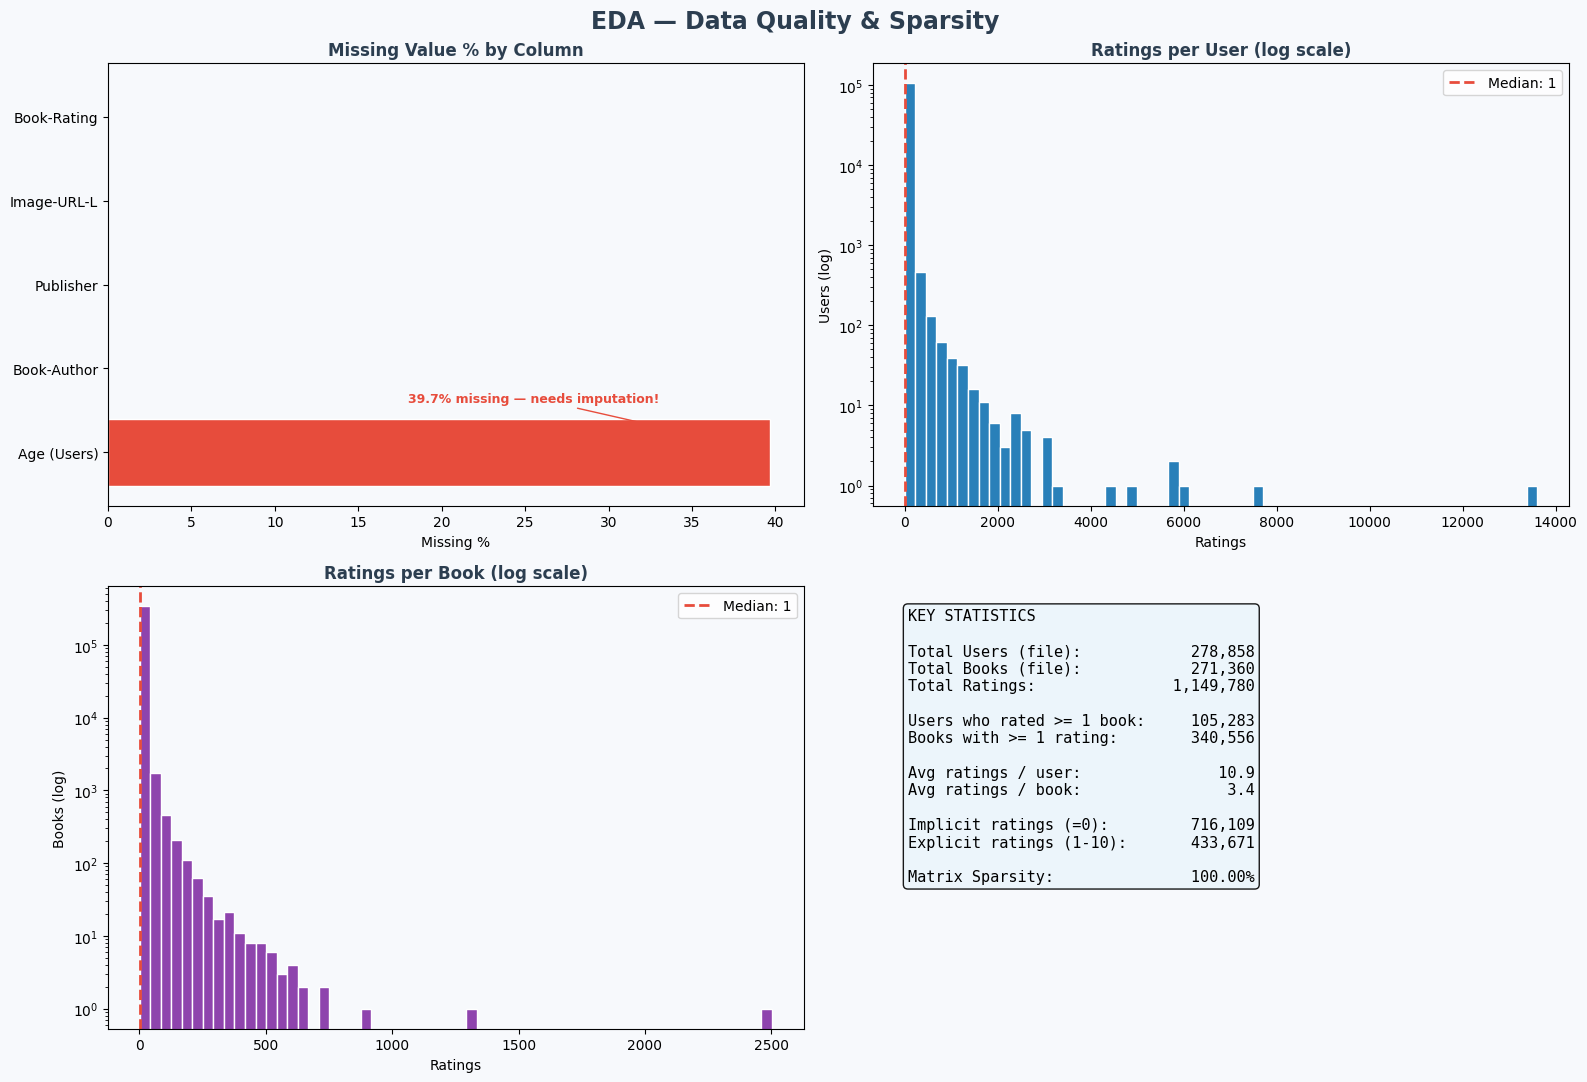

Saved: EDA_2_DataQuality.png


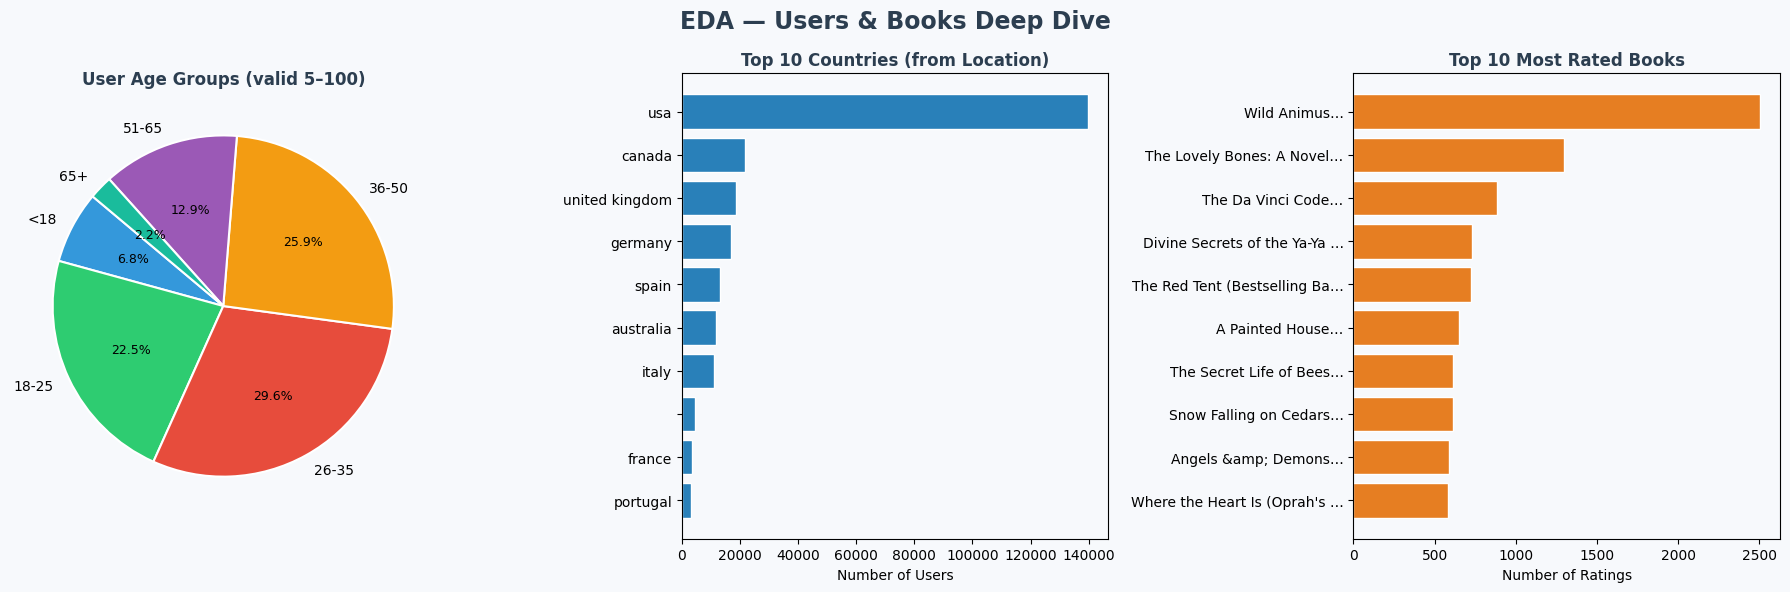

Saved: EDA_3_UserBooks.png


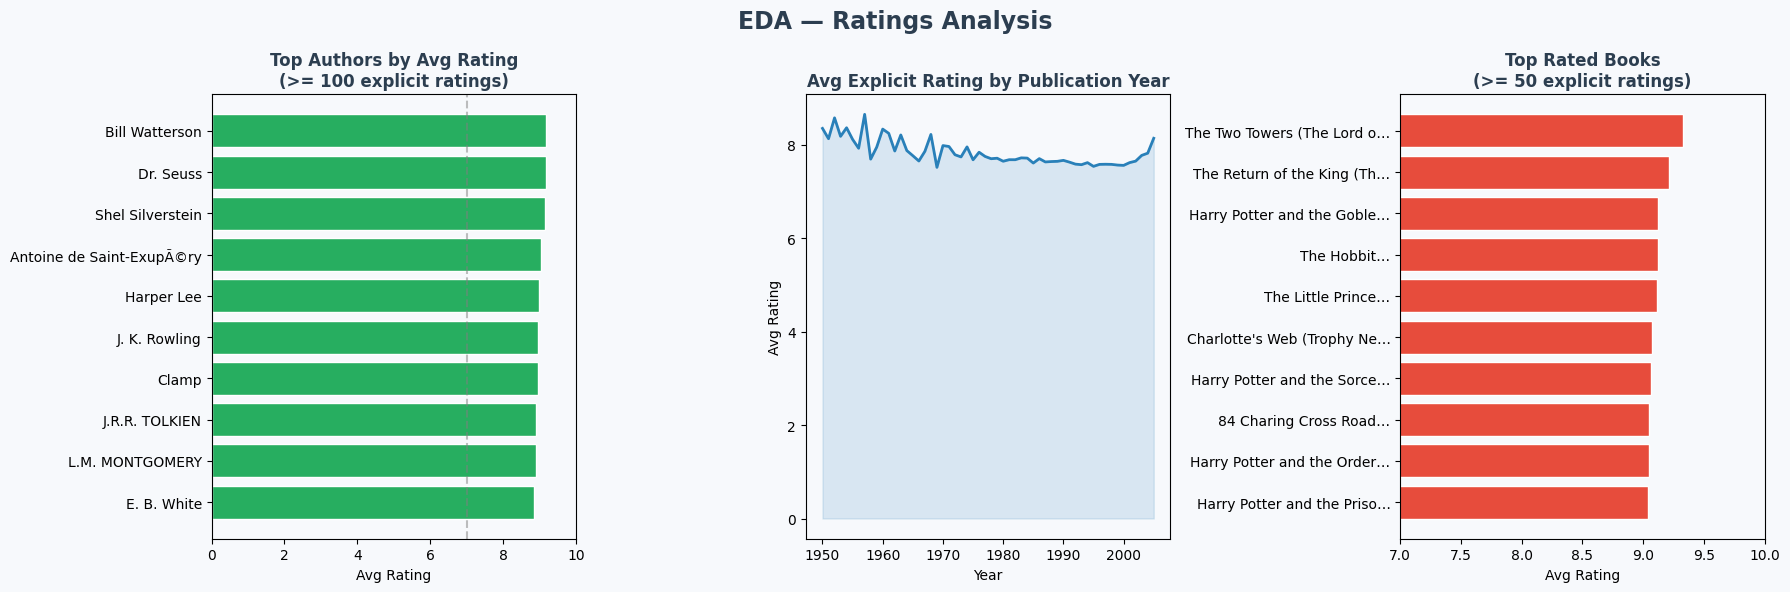

Saved: EDA_4_RatingAnalysis.png


In [6]:
# ----------------------------------------------------------------
# SECTION 5: EDA VISUALIZATIONS (ON RAW DATA)
# ----------------------------------------------------------------
print("\n" + "=" * 55)
print("  SECTION 5: EDA VISUALIZATIONS")
print("=" * 55)

BG      = '#F7F9FC'
DARK    = '#2C3E50'
BLUE    = '#2980B9'
RED     = '#E74C3C'
GREEN   = '#27AE60'
ORANGE  = '#E67E22'
PURPLE  = '#8E44AD'

# ── Chart 1: Overview (6 plots) ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor(BG)
fig.suptitle('EDA — Book Recommendation System (Raw Data)',
             fontsize=17, fontweight='bold', color=DARK)

# 1. All ratings distribution
rat_counts = ratings['Book-Rating'].value_counts().sort_index()
colors = [RED if v == 0 else BLUE for v in rat_counts.index]
axes[0,0].bar(rat_counts.index, rat_counts.values, color=colors, edgecolor='white', width=0.7)
axes[0,0].set_title('Rating Distribution (All)', fontweight='bold', color=DARK)
axes[0,0].set_xlabel('Rating (0 = implicit)'); axes[0,0].set_xticks(range(11))
axes[0,0].set_facecolor(BG)

# 2. Explicit ratings only (1-10)
explicit_raw = ratings[ratings['Book-Rating'] > 0]
exp_counts = explicit_raw['Book-Rating'].value_counts().sort_index()
axes[0,1].bar(exp_counts.index, exp_counts.values, color=GREEN, edgecolor='white', width=0.7)
axes[0,1].set_title('Explicit Ratings Only (1–10)', fontweight='bold', color=DARK)
axes[0,1].set_xlabel('Rating'); axes[0,1].set_xticks(range(1, 11))
axes[0,1].set_facecolor(BG)

# 3. Age distribution (valid only)
valid_age = users[(users['Age'] >= 5) & (users['Age'] <= 100)]['Age']
axes[0,2].hist(valid_age, bins=30, color=ORANGE, edgecolor='white')
axes[0,2].axvline(valid_age.median(), color=RED, linestyle='--', linewidth=2,
                   label=f'Median: {valid_age.median():.0f}')
axes[0,2].set_title('User Age Distribution', fontweight='bold', color=DARK)
axes[0,2].set_xlabel('Age'); axes[0,2].legend(); axes[0,2].set_facecolor(BG)

# 4. Publication year
valid_yr = books[(books['Year-Of-Publication'] >= 1900) &
                 (books['Year-Of-Publication'] <= 2023)]['Year-Of-Publication']
axes[1,0].hist(valid_yr, bins=40, color=PURPLE, edgecolor='white')
axes[1,0].set_title('Books by Publication Year', fontweight='bold', color=DARK)
axes[1,0].set_xlabel('Year'); axes[1,0].set_facecolor(BG)

# 5. Ratings per user (log)
rpu = ratings.groupby('User-ID').size()
axes[1,1].hist(rpu, bins=60, color=BLUE, edgecolor='white', log=True)
axes[1,1].axvline(rpu.median(), color=RED, linestyle='--', linewidth=2,
                   label=f'Median: {rpu.median():.0f}')
axes[1,1].set_title('Ratings per User (log)', fontweight='bold', color=DARK)
axes[1,1].set_xlabel('Number of Ratings'); axes[1,1].legend(); axes[1,1].set_facecolor(BG)

# 6. Ratings per book (log)
rpb = ratings.groupby('ISBN').size()
axes[1,2].hist(rpb, bins=60, color=RED, edgecolor='white', log=True)
axes[1,2].axvline(rpb.median(), color=DARK, linestyle='--', linewidth=2,
                   label=f'Median: {rpb.median():.0f}')
axes[1,2].set_title('Ratings per Book (log)', fontweight='bold', color=DARK)
axes[1,2].set_xlabel('Number of Ratings'); axes[1,2].legend(); axes[1,2].set_facecolor(BG)

plt.tight_layout()
plt.savefig('EDA_1_Overview.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved: EDA_1_Overview.png")

# ── Chart 2: Data Quality ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.patch.set_facecolor(BG)
fig.suptitle('EDA — Data Quality & Sparsity', fontsize=17, fontweight='bold', color=DARK)

# Missing % bar
ax = axes[0, 0]
miss_cols = ['Age (Users)', 'Book-Author', 'Publisher', 'Image-URL-L', 'Book-Rating']
miss_pcts = [39.7, 0.0007, 0.0007, 0.001, 0.0]
bar_colors = [RED if p > 1 else BLUE for p in miss_pcts]
ax.barh(miss_cols, miss_pcts, color=bar_colors, edgecolor='white')
ax.set_title('Missing Value % by Column', fontweight='bold', color=DARK)
ax.set_xlabel('Missing %'); ax.set_facecolor(BG)
ax.annotate('39.7% missing — needs imputation!',
            xy=(39.7, 0), xytext=(18, 0.6),
            fontsize=9, color=RED, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=RED))

# Ratings per user
ax = axes[0, 1]
ax.hist(rpu, bins=60, color=BLUE, edgecolor='white', log=True)
ax.axvline(rpu.median(), color=RED, linestyle='--', linewidth=2,
           label=f'Median: {rpu.median():.0f}')
ax.set_title('Ratings per User (log scale)', fontweight='bold', color=DARK)
ax.set_xlabel('Ratings'); ax.set_ylabel('Users (log)'); ax.legend(); ax.set_facecolor(BG)

# Ratings per book
ax = axes[1, 0]
ax.hist(rpb, bins=60, color=PURPLE, edgecolor='white', log=True)
ax.axvline(rpb.median(), color=RED, linestyle='--', linewidth=2,
           label=f'Median: {rpb.median():.0f}')
ax.set_title('Ratings per Book (log scale)', fontweight='bold', color=DARK)
ax.set_xlabel('Ratings'); ax.set_ylabel('Books (log)'); ax.legend(); ax.set_facecolor(BG)

# Key stats text
ax = axes[1, 1]
ax.axis('off')
n_u = ratings['User-ID'].nunique()
n_b = ratings['ISBN'].nunique()
sparsity = 1 - len(ratings) / (n_u * n_b)
txt = (
    "KEY STATISTICS\n\n"
    f"Total Users (file):         {len(users):>10,}\n"
    f"Total Books (file):         {len(books):>10,}\n"
    f"Total Ratings:              {len(ratings):>10,}\n\n"
    f"Users who rated >= 1 book:  {n_u:>10,}\n"
    f"Books with >= 1 rating:     {n_b:>10,}\n\n"
    f"Avg ratings / user:         {rpu.mean():>10.1f}\n"
    f"Avg ratings / book:         {rpb.mean():>10.1f}\n\n"
    f"Implicit ratings (=0):      {(ratings['Book-Rating']==0).sum():>10,}\n"
    f"Explicit ratings (1-10):    {(ratings['Book-Rating']>0).sum():>10,}\n\n"
    f"Matrix Sparsity:            {sparsity*100:>9.2f}%"
)
ax.text(0.05, 0.95, txt, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#EBF5FB', alpha=0.9))

plt.tight_layout()
plt.savefig('EDA_2_DataQuality.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved: EDA_2_DataQuality.png")

# ── Chart 3: Users & Books Deep Dive ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('EDA — Users & Books Deep Dive', fontsize=17, fontweight='bold', color=DARK)

# Age group pie
ax = axes[0]
bins_age   = [0, 17, 25, 35, 50, 65, 100]
labels_age = ['<18', '18-25', '26-35', '36-50', '51-65', '65+']
age_grp = pd.cut(valid_age, bins=bins_age, labels=labels_age).value_counts().reindex(labels_age)
pie_colors = ['#3498DB','#2ECC71','#E74C3C','#F39C12','#9B59B6','#1ABC9C']
wedges, texts, autotexts = ax.pie(age_grp, labels=labels_age, autopct='%1.1f%%',
                                   colors=pie_colors, startangle=140,
                                   wedgeprops=dict(edgecolor='white', linewidth=1.5))
for t in autotexts: t.set_fontsize(9)
ax.set_title('User Age Groups (valid 5–100)', fontweight='bold', color=DARK)

# Top 10 countries
ax = axes[1]
users['Country'] = users['Location'].apply(
    lambda x: x.split(',')[-1].strip() if isinstance(x, str) else 'unknown')
top_c = users['Country'].value_counts().head(10)
ax.barh(top_c.index[::-1], top_c.values[::-1], color=BLUE, edgecolor='white')
ax.set_title('Top 10 Countries (from Location)', fontweight='bold', color=DARK)
ax.set_xlabel('Number of Users'); ax.set_facecolor(BG)

# Most rated books
ax = axes[2]
top_books = (ratings.groupby('ISBN').size().reset_index(name='n')
             .merge(books[['ISBN','Book-Title']], on='ISBN')
             .nlargest(10, 'n'))
top_books['Short'] = top_books['Book-Title'].str[:28] + '…'
ax.barh(top_books['Short'][::-1], top_books['n'][::-1], color=ORANGE, edgecolor='white')
ax.set_title('Top 10 Most Rated Books', fontweight='bold', color=DARK)
ax.set_xlabel('Number of Ratings'); ax.set_facecolor(BG)

plt.tight_layout()
plt.savefig('EDA_3_UserBooks.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved: EDA_3_UserBooks.png")

# ── Chart 4: Ratings Analysis ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('EDA — Ratings Analysis', fontsize=17, fontweight='bold', color=DARK)

merged_raw = explicit_raw.merge(
    books[['ISBN','Book-Author','Year-Of-Publication','Book-Title']], on='ISBN', how='left')

# Top authors by avg rating
ax = axes[0]
auth = (merged_raw.groupby('Book-Author')['Book-Rating']
        .agg(['mean','count']).query('count >= 100')
        .nlargest(10, 'mean'))
ax.barh(auth.index[::-1], auth['mean'][::-1], color=GREEN, edgecolor='white')
ax.set_xlim(0, 10); ax.axvline(7, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Top Authors by Avg Rating\n(>= 100 explicit ratings)', fontweight='bold', color=DARK)
ax.set_xlabel('Avg Rating'); ax.set_facecolor(BG)

# Avg rating by year
ax = axes[1]
yr_avg = (merged_raw[(merged_raw['Year-Of-Publication'] >= 1950) &
                     (merged_raw['Year-Of-Publication'] <= 2005)]
          .groupby('Year-Of-Publication')['Book-Rating'].mean())
ax.plot(yr_avg.index, yr_avg.values, color=BLUE, linewidth=2)
ax.fill_between(yr_avg.index, yr_avg.values, alpha=0.15, color=BLUE)
ax.set_title('Avg Explicit Rating by Publication Year', fontweight='bold', color=DARK)
ax.set_xlabel('Year'); ax.set_ylabel('Avg Rating'); ax.set_facecolor(BG)

# Top rated books
ax = axes[2]
bk = (merged_raw.groupby('Book-Title')['Book-Rating']
      .agg(['mean','count']).query('count >= 50')
      .nlargest(10, 'mean'))
short_t = [t[:26]+'…' for t in bk.index]
ax.barh(short_t[::-1], bk['mean'][::-1], color=RED, edgecolor='white')
ax.set_xlim(7, 10)
ax.set_title('Top Rated Books\n(>= 50 explicit ratings)', fontweight='bold', color=DARK)
ax.set_xlabel('Avg Rating'); ax.set_facecolor(BG)

plt.tight_layout()
plt.savefig('EDA_4_RatingAnalysis.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved: EDA_4_RatingAnalysis.png")



  SECTION 6: DATA CLEANING

[6A] Cleaning Users...
  Age median used for imputation : 32.0
  Invalid/missing ages fixed     : 222,772
  Remaining nulls in users       : 0

[6B] Cleaning Books...
  Year median used for imputation : 1996.0
  Invalid year entries fixed      : 4,635
  Duplicate ISBNs removed         : 0
  Image URL columns dropped       : 3
  Remaining nulls in books        : 0

[6C] Cleaning Ratings...
  Duplicate rows removed : 0
  Implicit ratings (=0)  : 716,109
  Explicit ratings (1-10): 433,671
  After cold-start filter (>= 3 ratings): 211,356

[6D] Creating final merged dataset...
  Final dataset shape   : (202071, 10)
  Columns               : ['User-ID', 'ISBN', 'Book-Rating', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Location', 'Age', 'Country']
  Null values remaining : 0

   User-ID        ISBN  Book-Rating                         Book-Title  \
0   276747  0060517794            9           Little Altars Everywhere   
1   276747  0671537

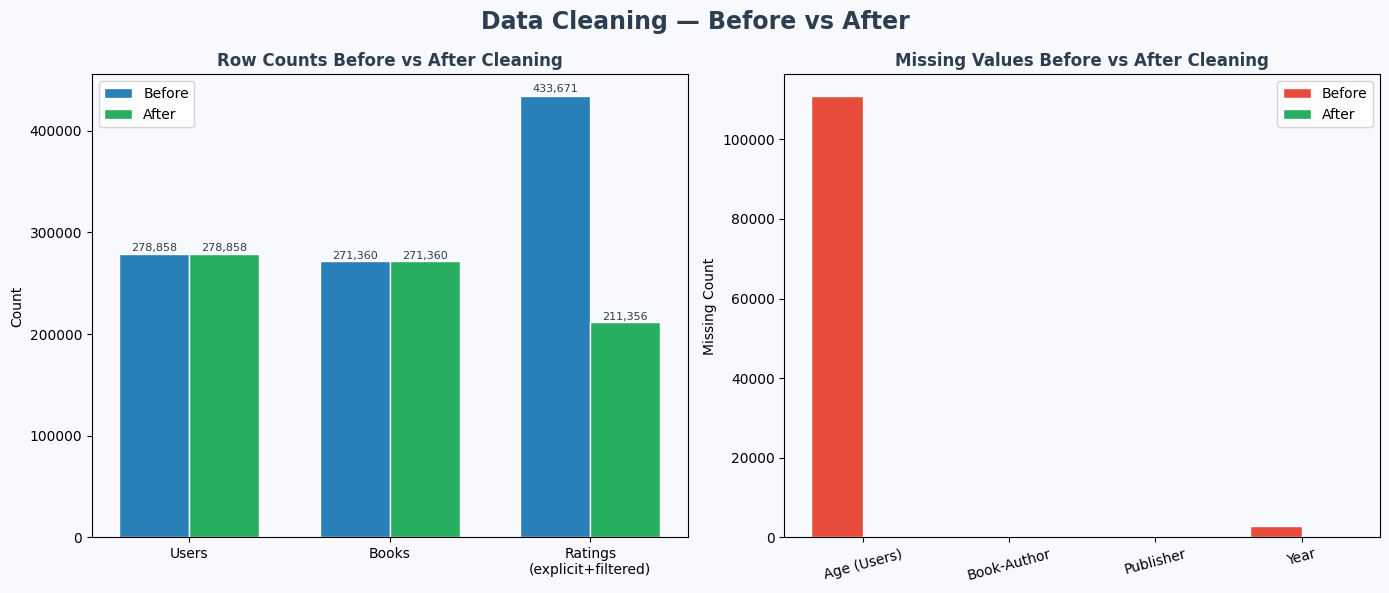


Saved: EDA_5_CleaningComparison.png


In [7]:
# ================================================================
# SECTION 6: DATA CLEANING
# ================================================================
print("\n" + "=" * 55)
print("  SECTION 6: DATA CLEANING")
print("=" * 55)

# ── 6A: Clean Users ──────────────────────────────────────────────
print("\n[6A] Cleaning Users...")
users_clean = users.copy()

# Replace invalid ages with NaN, then impute with median
valid_mask = (users_clean['Age'] >= 5) & (users_clean['Age'] <= 100)
age_median = users_clean.loc[valid_mask, 'Age'].median()
users_clean.loc[~valid_mask, 'Age'] = np.nan
users_clean['Age'] = users_clean['Age'].fillna(age_median).astype('Int64')

print(f"  Age median used for imputation : {age_median}")
print(f"  Invalid/missing ages fixed     : {(~valid_mask).sum() + users['Age'].isnull().sum():,}")
print(f"  Remaining nulls in users       : {users_clean.isnull().sum().sum()}")

# ── 6B: Clean Books ──────────────────────────────────────────────
print("\n[6B] Cleaning Books...")
books_clean = books.copy()

# Drop image URL columns (not useful for modeling)
books_clean.drop(columns=['Image-URL-S', 'Image-URL-M', 'Image-URL-L'], inplace=True)

# Fill missing Author and Publisher
books_clean['Book-Author'] = books_clean['Book-Author'].fillna('Unknown')
books_clean['Publisher']   = books_clean['Publisher'].fillna('Unknown')

# Fix invalid years → impute with median
valid_yr_mask = (books_clean['Year-Of-Publication'] >= 1800) & \
                (books_clean['Year-Of-Publication'] <= 2024)
year_median = books_clean.loc[valid_yr_mask, 'Year-Of-Publication'].median()
books_clean.loc[~valid_yr_mask, 'Year-Of-Publication'] = np.nan
books_clean['Year-Of-Publication'] = books_clean['Year-Of-Publication'] \
                                         .fillna(year_median).astype('Int64')

# Remove duplicate ISBNs
dupes_before = books_clean.duplicated(subset='ISBN').sum()
books_clean.drop_duplicates(subset='ISBN', inplace=True)

print(f"  Year median used for imputation : {year_median}")
print(f"  Invalid year entries fixed      : {(~valid_yr_mask).sum():,}")
print(f"  Duplicate ISBNs removed         : {dupes_before}")
print(f"  Image URL columns dropped       : 3")
print(f"  Remaining nulls in books        : {books_clean.isnull().sum().sum()}")

# ── 6C: Clean Ratings ────────────────────────────────────────────
print("\n[6C] Cleaning Ratings...")
ratings_clean = ratings.drop_duplicates()
dupes_removed = len(ratings) - len(ratings_clean)
print(f"  Duplicate rows removed : {dupes_removed:,}")

# Separate implicit (0) and explicit (1-10)
ratings_implicit = ratings_clean[ratings_clean['Book-Rating'] == 0].copy()
ratings_explicit = ratings_clean[ratings_clean['Book-Rating'] >  0].copy()
print(f"  Implicit ratings (=0)  : {len(ratings_implicit):,}")
print(f"  Explicit ratings (1-10): {len(ratings_explicit):,}")

# Cold-start filter: keep users & books with >= 3 explicit ratings
user_counts   = ratings_explicit['User-ID'].value_counts()
book_counts   = ratings_explicit['ISBN'].value_counts()
active_users  = user_counts[user_counts >= 3].index
popular_books = book_counts[book_counts >= 3].index

ratings_filtered = ratings_explicit[
    ratings_explicit['User-ID'].isin(active_users) &
    ratings_explicit['ISBN'].isin(popular_books)
].copy()

print(f"  After cold-start filter (>= 3 ratings): {len(ratings_filtered):,}")


# ── 6D: Final Merged Dataset ─────────────────────────────────────
print("\n[6D] Creating final merged dataset...")
final_df = (ratings_filtered
            .merge(books_clean,  on='ISBN',    how='inner')
            .merge(users_clean,  on='User-ID', how='inner'))

print(f"  Final dataset shape   : {final_df.shape}")
print(f"  Columns               : {final_df.columns.tolist()}")
print(f"  Null values remaining : {final_df.isnull().sum().sum()}")
print(f"\n{final_df.head(5)}")


# ── 6E: Save cleaned files ───────────────────────────────────────
users_clean.to_csv('users_cleaned.csv',           index=False)
books_clean.to_csv('books_cleaned.csv',            index=False)
ratings_filtered.to_csv('ratings_cleaned.csv',     index=False)
final_df.to_csv('final_dataset.csv',               index=False)
print("\n  Saved: users_cleaned.csv")
print("  Saved: books_cleaned.csv")
print("  Saved: ratings_cleaned.csv")
print("  Saved: final_dataset.csv  ← USE THIS FOR MODELING")


# ── 6F: Before vs After Summary Chart ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Data Cleaning — Before vs After', fontsize=17, fontweight='bold', color=DARK)

# Row counts comparison
ax = axes[0]
categories = ['Users', 'Books', 'Ratings\n(explicit+filtered)']
before = [278858, 271360, 433671]
after  = [len(users_clean), len(books_clean), len(ratings_filtered)]
x = np.arange(len(categories))
w = 0.35
bars1 = ax.bar(x - w/2, before, w, label='Before', color=BLUE,   edgecolor='white')
bars2 = ax.bar(x + w/2, after,  w, label='After',  color=GREEN,  edgecolor='white')
ax.set_title('Row Counts Before vs After Cleaning', fontweight='bold', color=DARK)
ax.set_xticks(x); ax.set_xticklabels(categories)
ax.set_ylabel('Count'); ax.legend(); ax.set_facecolor(BG)
for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                           f'{bar.get_height():,}', ha='center', fontsize=8, color=DARK)
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                           f'{bar.get_height():,}', ha='center', fontsize=8, color=DARK)

# Null values comparison
ax = axes[1]
null_before = {'Age (Users)': 110762, 'Book-Author': 2, 'Publisher': 2, 'Year': 3000}
null_after  = {'Age (Users)': 0, 'Book-Author': 0, 'Publisher': 0, 'Year': 0}
cols  = list(null_before.keys())
bvals = list(null_before.values())
avals = list(null_after.values())
x2 = np.arange(len(cols))
ax.bar(x2 - w/2, bvals, w, label='Before', color=RED,   edgecolor='white')
ax.bar(x2 + w/2, avals, w, label='After',  color=GREEN, edgecolor='white')
ax.set_title('Missing Values Before vs After Cleaning', fontweight='bold', color=DARK)
ax.set_xticks(x2); ax.set_xticklabels(cols, rotation=15)
ax.set_ylabel('Missing Count'); ax.legend(); ax.set_facecolor(BG)

plt.tight_layout()
plt.savefig('EDA_5_CleaningComparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("\nSaved: EDA_5_CleaningComparison.png")


In [8]:
# ================================================================
# SECTION 7: FINAL SUMMARY
# ================================================================
print("\n" + "=" * 55)
print("  SECTION 7: FINAL SUMMARY")
print("=" * 55)
print(f"""
EDA FINDINGS:
  - 62.3% of ratings are implicit (=0)
  - Age had 39.7% missing → imputed with median (32)
  - Year had invalid values → imputed with median (1996)
  - Matrix sparsity ~99.99% (normal for recommendation systems)
  - Cold-start problem: most users/books have very few ratings

CLEANING DONE:
  - Age: invalid values replaced, missing imputed with median
  - Year: invalid values replaced, missing imputed with median
  - Image URL columns dropped (not useful for modeling)
  - Duplicate rows removed from Ratings
  - Cold-start filter: kept users/books with >= 3 ratings
  - Implicit ratings separated (use for future implicit models)

FILES SAVED:
  users_cleaned.csv          → cleaned user data
  books_cleaned.csv          → cleaned book data
  ratings_cleaned.csv        → explicit ratings, filtered
  final_dataset.csv          → merged, model-ready dataset ✓

NEXT STEP → Model Building:
  1. Popularity-based model  (baseline)
  2. Collaborative Filtering (user-user or item-item)
  3. Matrix Factorization     (SVD)
""")



  SECTION 7: FINAL SUMMARY

EDA FINDINGS:
  - 62.3% of ratings are implicit (=0)
  - Age had 39.7% missing → imputed with median (32)
  - Year had invalid values → imputed with median (1996)
  - Matrix sparsity ~99.99% (normal for recommendation systems)
  - Cold-start problem: most users/books have very few ratings

CLEANING DONE:
  - Age: invalid values replaced, missing imputed with median
  - Year: invalid values replaced, missing imputed with median
  - Image URL columns dropped (not useful for modeling)
  - Duplicate rows removed from Ratings
  - Cold-start filter: kept users/books with >= 3 ratings
  - Implicit ratings separated (use for future implicit models)

FILES SAVED:
  users_cleaned.csv          → cleaned user data
  books_cleaned.csv          → cleaned book data
  ratings_cleaned.csv        → explicit ratings, filtered
  final_dataset.csv          → merged, model-ready dataset ✓

NEXT STEP → Model Building:
  1. Popularity-based model  (baseline)
  2. Collaborative Fil

In [9]:
from collections import defaultdict

In [10]:
np.random.seed(42)

RANDOM_STATE = 42
TOP_K = 10              # for Precision@K / Recall@K
RATING_THRESHOLD = 7    # rating >= 7 counts as "relevant" for ranking metrics
N_FACTORS = 30          # SVD latent factors

sns.set_style('whitegrid')

## 8. Train / Test Split

In [11]:
from sklearn.model_selection import train_test_split

ratings_df = final_df[['User-ID', 'ISBN', 'Book-Rating']].copy()

train_df, test_df = train_test_split(
    ratings_df, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train ratings: {len(train_df):,}")
print(f"Test  ratings: {len(test_df):,}")
print(f"Unique users in train: {train_df['User-ID'].nunique():,}")
print(f"Unique books in train: {train_df['ISBN'].nunique():,}")


Train ratings: 161,656
Test  ratings: 40,415
Unique users in train: 19,970
Unique books in train: 27,418


## 9. Build the User–Item Matrix

In [12]:
user_item_train = train_df.pivot_table(
    index='User-ID', columns='ISBN', values='Book-Rating'
)

print(f"User-Item matrix shape: {user_item_train.shape}")
sparsity = 1 - train_df.shape[0] / (user_item_train.shape[0] * user_item_train.shape[1])
print(f"Sparsity: {sparsity*100:.3f}%")

# Filled-with-0 version for similarity computations
user_item_filled = user_item_train.fillna(0)

User-Item matrix shape: (19970, 27418)
Sparsity: 99.970%


## 10. Model 1 — Popularity-Based Baseline

In [13]:
book_stats = train_df.groupby('ISBN')['Book-Rating'].agg(['mean', 'count']).reset_index()
book_stats.columns = ['ISBN', 'avg_rating', 'num_ratings']

C = book_stats['num_ratings'].mean()       # avg number of ratings per book
m = book_stats['avg_rating'].mean()        # global average rating

# Bayesian-average popularity score
book_stats['popularity_score'] = (
    (book_stats['num_ratings'] / (book_stats['num_ratings'] + C)) * book_stats['avg_rating']
    + (C / (book_stats['num_ratings'] + C)) * m
)

global_mean_rating = train_df['Book-Rating'].mean()

def popularity_predict_rating(user_id, isbn):
    """Predicted rating = book's overall average rating (fallback: global mean)."""
    row = book_stats.loc[book_stats['ISBN'] == isbn, 'avg_rating']
    return row.values[0] if len(row) else global_mean_rating

top_popular_books = book_stats.sort_values('popularity_score', ascending=False)

def popularity_recommend(user_id, k=TOP_K, exclude_seen=None):
    recs = top_popular_books['ISBN'].tolist()
    if exclude_seen:
        recs = [b for b in recs if b not in exclude_seen]
    return recs[:k]

book_stats.sort_values('popularity_score', ascending=False).head(10)

,ISBN,avg_rating,num_ratings,popularity_score
10273,0439425220,9.937500,16,9.318811
16652,0618002235,9.789474,19,9.280394
10222,0439139597,9.315217,92,9.214316
503,0060256656,9.705882,17,9.173859
4939,0345339738,9.339623,53,9.169463
23031,0877017883,9.382353,34,9.124842
25514,1888054557,10.000000,10,9.124602
10220,0439136369,9.206522,92,9.112167
8895,039480001X,9.523810,21,9.110822
10219,0439136350,9.186275,102,9.101771


## 11. Model 2 — Collaborative Filtering (Cosine Similarity)

Two variants:
- **Item-Item**: recommend books similar to ones a user already rated highly
- **User-User**: recommend books that similar users rated highly

Cosine similarity is computed on the user-item matrix (memory-based CF).


In [14]:
from sklearn.metrics.pairwise import cosine_similarity

# ---- Item-Item similarity ----
item_sim = cosine_similarity(user_item_filled.T.values)
item_sim_df = pd.DataFrame(item_sim, index=user_item_filled.columns, columns=user_item_filled.columns)

# ---- User-User similarity ----
user_sim = cosine_similarity(user_item_filled.values)
user_sim_df = pd.DataFrame(user_sim, index=user_item_filled.index, columns=user_item_filled.index)

print("Item-Item similarity matrix:", item_sim_df.shape)
print("User-User similarity matrix:", user_sim_df.shape)


Item-Item similarity matrix: (27418, 27418)
User-User similarity matrix: (19970, 19970)


In [15]:
def cf_item_predict_rating(user_id, isbn, k_neighbors=20):
    if isbn not in item_sim_df.columns or user_id not in user_item_train.index:
        return global_mean_rating
    user_ratings = user_item_train.loc[user_id].dropna()
    if user_ratings.empty:
        return global_mean_rating
    sims = item_sim_df[isbn].drop(isbn, errors='ignore')
    sims = sims[user_ratings.index.intersection(sims.index)]
    sims = sims.sort_values(ascending=False).head(k_neighbors)
    sims = sims[sims > 0]
    if sims.empty:
        return global_mean_rating
    weighted = (sims * user_ratings[sims.index]).sum() / sims.sum()
    return weighted

def cf_user_predict_rating(user_id, isbn, k_neighbors=20):
    if user_id not in user_sim_df.index or isbn not in user_item_train.columns:
        return global_mean_rating
    book_ratings = user_item_train[isbn].dropna()
    if book_ratings.empty:
        return global_mean_rating
    sims = user_sim_df[user_id].drop(user_id, errors='ignore')
    sims = sims[book_ratings.index.intersection(sims.index)]
    sims = sims.sort_values(ascending=False).head(k_neighbors)
    sims = sims[sims > 0]
    if sims.empty:
        return global_mean_rating
    weighted = (sims * book_ratings[sims.index]).sum() / sims.sum()
    return weighted


## 12. Model 3 — Matrix Factorization (SVD)

In [16]:
from sklearn.decomposition import TruncatedSVD

# Mean-center each user's ratings (subtract user's average) before factorizing
user_means = user_item_train.mean(axis=1)
matrix_centered = user_item_train.sub(user_means, axis=0).fillna(0)

svd = TruncatedSVD(n_components=N_FACTORS, random_state=RANDOM_STATE)
user_factors = svd.fit_transform(matrix_centered.values)
book_factors = svd.components_.T

pred_matrix = np.dot(user_factors, book_factors.T) + user_means.values.reshape(-1, 1)
pred_df = pd.DataFrame(pred_matrix, index=user_item_train.index, columns=user_item_train.columns)

print(f"Explained variance ratio (sum): {svd.explained_variance_ratio_.sum():.3f}")

def svd_predict_rating(user_id, isbn):
    if user_id in pred_df.index and isbn in pred_df.columns:
        return np.clip(pred_df.loc[user_id, isbn], 1, 10)
    return global_mean_rating

Explained variance ratio (sum): 0.115


## 13. Rating-Accuracy Evaluation — RMSE & MAE

Predict a rating for every (user, book) pair in the **test set** and compare to the
true rating.


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_rmse_mae(predict_fn, name):
    y_true, y_pred = [], []
    for _, row in test_df.iterrows():
        y_true.append(row['Book-Rating'])
        y_pred.append(predict_fn(row['User-ID'], row['ISBN']))
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f"{name:20s}  RMSE = {rmse:.4f}   MAE = {mae:.4f}")
    return rmse, mae

print("Evaluating rating-prediction accuracy on the test set...\n")
results_rating = {}
results_rating['Popularity']        = evaluate_rmse_mae(popularity_predict_rating, 'Popularity')
results_rating['CF (Item-Item)']    = evaluate_rmse_mae(cf_item_predict_rating,    'CF (Item-Item)')
results_rating['CF (User-User)']    = evaluate_rmse_mae(cf_user_predict_rating,    'CF (User-User)')
results_rating['SVD']               = evaluate_rmse_mae(svd_predict_rating,        'SVD')


Evaluating rating-prediction accuracy on the test set...



## 14. Ranking Evaluation — Precision@K & Recall@K

A book is **"relevant"** to a user if their true test rating is `>= RATING_THRESHOLD`.
For each user, we generate a Top-K recommendation list and check how many of those
recommended books were actually relevant in the held-out test set.


In [ ]:
# Ground truth: relevant books per user in the TEST set
relevant_items = defaultdict(set)
for _, row in test_df.iterrows():
    if row['Book-Rating'] >= RATING_THRESHOLD:
        relevant_items[row['User-ID']].add(row['ISBN'])

# Books each user already rated in TRAIN (to exclude from recommendations)
seen_items = defaultdict(set)
for _, row in train_df.iterrows():
    seen_items[row['User-ID']].add(row['ISBN'])

all_books = list(user_item_train.columns)
eval_users = [u for u in relevant_items if u in user_item_train.index]
print(f"Users with at least one relevant test item: {len(eval_users):,}")

def topk_via_score_fn(user_id, score_fn, k=TOP_K, candidate_pool=None):
    candidates = candidate_pool if candidate_pool is not None else all_books
    candidates = [b for b in candidates if b not in seen_items[user_id]]
    scored = [(b, score_fn(user_id, b)) for b in candidates]
    scored.sort(key=lambda x: x[1], reverse=True)
    return [b for b, _ in scored[:k]]

def precision_recall_at_k(rec_fn, name, sample_size=300):
    # Sample users for speed on large datasets; increase sample_size for a fuller eval
    sample_users = np.random.choice(eval_users, size=min(sample_size, len(eval_users)), replace=False)
    precisions, recalls = [], []
    for u in sample_users:
        recs = rec_fn(u)
        hits = len(set(recs) & relevant_items[u])
        precisions.append(hits / TOP_K)
        recalls.append(hits / len(relevant_items[u]))
    p, r = np.mean(precisions), np.mean(recalls)
    print(f"{name:20s}  Precision@{TOP_K} = {p:.4f}   Recall@{TOP_K} = {r:.4f}")
    return p, r


In [ ]:
print(f"Evaluating ranking quality (Precision@{TOP_K} / Recall@{TOP_K}) on a user sample...\n")

results_rank = {}
results_rank['Popularity'] = precision_recall_at_k(
    lambda u: popularity_recommend(u, k=TOP_K, exclude_seen=seen_items[u]), 'Popularity')

results_rank['CF (Item-Item)'] = precision_recall_at_k(
    lambda u: topk_via_score_fn(u, cf_item_predict_rating), 'CF (Item-Item)')

results_rank['CF (User-User)'] = precision_recall_at_k(
    lambda u: topk_via_score_fn(u, cf_user_predict_rating), 'CF (User-User)')

results_rank['SVD'] = precision_recall_at_k(
    lambda u: topk_via_score_fn(u, svd_predict_rating), 'SVD')


## 15. Model Comparison Summary

In [ ]:
summary = pd.DataFrame({
    'Model':       list(results_rating.keys()),
    'RMSE':        [v[0] for v in results_rating.values()],
    'MAE':         [v[1] for v in results_rating.values()],
    f'Precision@{TOP_K}': [results_rank[m][0] for m in results_rating.keys()],
    f'Recall@{TOP_K}':    [results_rank[m][1] for m in results_rating.keys()],
}).sort_values('RMSE')

print(summary.to_string(index=False))
summary


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(summary['Model'], summary['RMSE'], color='#4C72B0')
axes[0].set_title('RMSE by Model (lower = better)')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(summary['Model'], summary['MAE'], color='#55A868')
axes[1].set_title('MAE by Model (lower = better)')
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(summary['Model'], summary[f'Precision@{TOP_K}'], color='#C44E52', label=f'Precision@{TOP_K}')
axes[2].bar(summary['Model'], summary[f'Recall@{TOP_K}'], color='#8172B2', alpha=0.5, label=f'Recall@{TOP_K}')
axes[2].set_title(f'Precision@{TOP_K} vs Recall@{TOP_K} (higher = better)')
axes[2].tick_params(axis='x', rotation=20)
axes[2].legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
